# Домашнее задание 4: Исследование линейной регрессии
## Датасет
 
Q: Что представляет собой датасет?

A: Используется датасет с информацией об автомобилях Toyota Corolla. Признаки включают различные характеристики автомобиля:
- возраст
- пробег
- мощность двигателя
- тип топлива
- и др.

Q: Что является целевой переменной?

A: `Price`, мы хотим её предсказывать.

Задача на сегодня - построить модель линейной регрессии, которая сможет предсказывать цену автомобиля на основе этих признаков.

In [1]:
import pandas as pd
df = pd.read_csv('ToyotaCorolla.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [3]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.columns

Index(['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors',
       'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee',
       'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2',
       'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player',
       'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
       'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'],
      dtype='str')

## EDA и предобработка
### EDA и предобработка(именно то, что написано на упаковке)

Q: Как вы предобрабатывали данные?

A: Проверили на пропущенные значения

### Проверка пропусков

In [5]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

### Анализ распределений

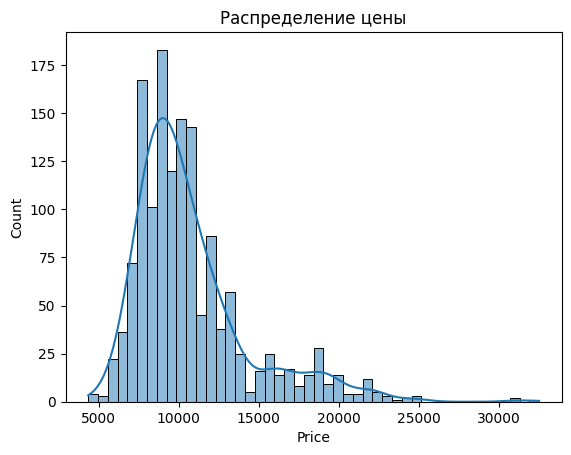

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], kde=True)
plt.title('Распределение цены')
plt.show()

Выраженный положительный скос: основная масса сосредоточена в диапазоне 7–12k и есть пара-тройка выбросов выше 25k

### Корреляции

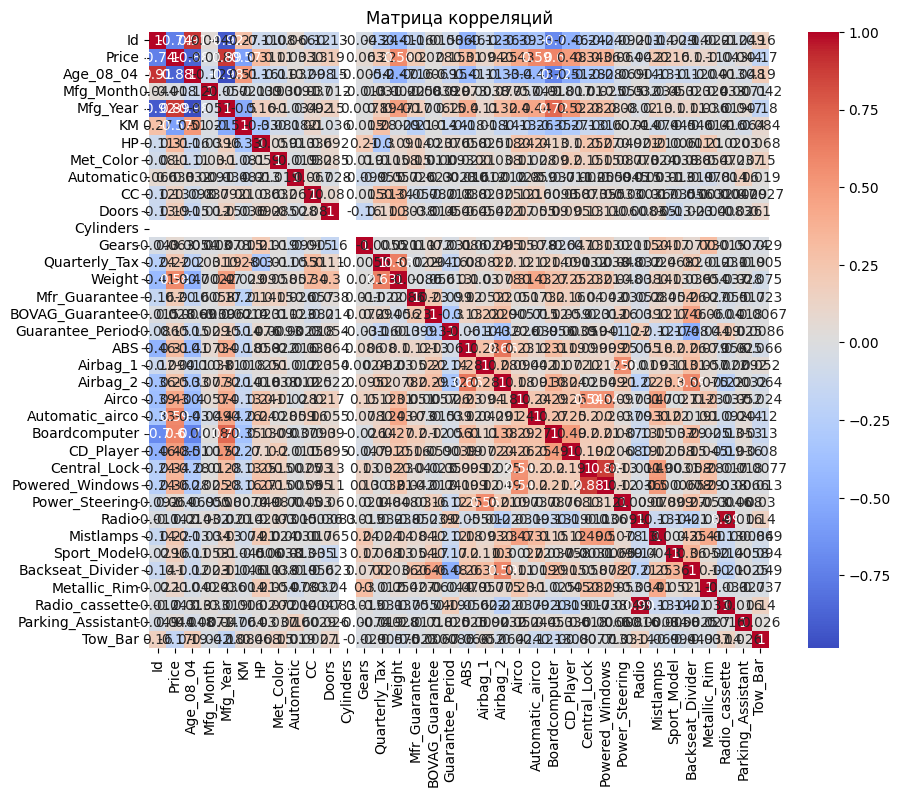

In [7]:
corr_matrix = df.corr(numeric_only=True)# корреляционная матрица
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Price:Сильная отрицательная корреляция с возрастом ```Age_08_04: -0.88``` и пробегом ```KM: -0.57```: чем старше машина и больше пробег, тем ниже цена. Заметная положительная корреляция с весом ```Weight: 0.58``` и годом выпуска ```Mfg_Year: 0.91``` (по сути дублирует возраст).

Q: Что вы поняли, проведя EDA?

A: Пропусков нет, распределение цен обладает правосторонней ассиметрией. Обнаружена мультиколлинеарность между `Age_08_04` и `Mfg_Year`

### Категориальные признаки

In [8]:
df.select_dtypes(include='object').columns

C:\Users\kilom\AppData\Local\Temp\ipykernel_27500\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Model', 'Fuel_Type', 'Color'], dtype='str')

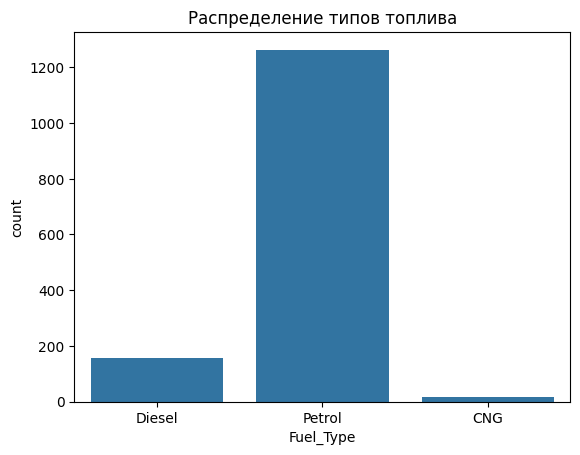

In [9]:
sns.countplot(x='Fuel_Type', data=df)
plt.title('Распределение типов топлива')
plt.show()

Категориальные признаки были проанализированы отдельно. Они требуют кодирования перед использованием в модели.

Большинство автомобилей бензиновые, доля дизельных и газовых крайне незначительна.

### Обработка категориальных переменных

In [10]:
df = df.drop(columns=['Model'], errors='ignore')
df = pd.get_dummies(df, drop_first=True)


`Model` удален: содержит слишком много уникальных значений, это бы привело к очень большому  количеству признаков после кодирования -> риск переобучения.

### Масштабирование признаков

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns = df.columns # названия колонок
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=columns) # масштаб
df_scaled.head()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,-1.730723,0.763763,-1.771966,1.327576,1.541796,-0.574695,-0.768042,0.694219,-0.242893,0.997419,...,-2.710874,-0.391681,2.018466,-0.425348,-0.514974,-0.489968,-0.304707,-0.052852,-0.14854,-0.045755
1,-1.728321,0.832715,-1.771966,1.327576,1.541796,0.117454,-0.768042,0.694219,-0.242893,0.997419,...,-2.710874,-0.391681,-0.495426,-0.425348,-0.514974,-0.489968,3.281843,-0.052852,-0.14854,-0.045755
2,-1.725919,0.887877,-1.718184,1.029329,1.541796,-0.715386,-0.768042,0.694219,-0.242893,0.997419,...,-2.710874,-0.391681,2.018466,-0.425348,-0.514974,-0.489968,-0.304707,-0.052852,-0.14854,-0.045755
3,-1.723517,1.163685,-1.610620,0.432833,1.541796,-0.547650,-0.768042,-1.440467,-0.242893,0.997419,...,-2.710874,2.553101,-0.495426,-0.425348,-0.514974,-0.489968,-0.304707,-0.052852,-0.14854,-0.045755
4,-1.721115,0.832715,-1.395491,-0.760158,1.541796,-0.801028,-0.768042,-1.440467,-0.242893,0.997419,...,-2.710874,2.553101,-0.495426,-0.425348,-0.514974,-0.489968,-0.304707,-0.052852,-0.14854,-0.045755


### Итог
Проверили пропуски, изучили распредление признаков, масштабировали данные, закодировали категориальные признаки, нашли наиболее значимые используя корреляцию.

Пропуски отсутствуют во всех 1436 записях. `Price` имеет правостороннюю асимметрию, основная масса авто в сегменте 7–12к. Сильная обратная связь цены с возрастом и пробегом.

## Работа с признаками (Feature Engineering)

Преобразовываем и отбираем признаки с целью улучшения качества модели. Линейная регрессия чувствительна к признаковому пространству, значит важно удалить нерелевантные признаки, создать новые информативные и устранить мультиколлинеарность

In [ ]:
to_drop = ['Id', 'Mfg_Year', 'Cylinders', 'Radio_cassette']
df = df.drop(columns=[col for col in to_drop if col in df.columns])
print(f"Осталось признаков: {df.shape[1]}")

Осталось признаков: 43


Q: Какие признаки вы удалили и почему?

A: `Id` (неинформативен), `Cylinders` (отсутствие вариативности) и `Mfg_Year` (полное дублирование признака `Age_08_04`). Это необходимо для устранения мультиколлинеарности, которая делает коэффициенты модели нестабильными.

In [ ]:
import numpy as np

corr_matrix = df.corr(numeric_only=True)
high_corr = np.where(abs(corr_matrix) > 0.8)# сильно коррелирующие признаки
high_corr_pairs = [
    (corr_matrix.columns[i], corr_matrix.columns[j])
    for i, j in zip(*high_corr)
    if i!=j and i<j
]
high_corr_pairs[:10]

[('Price', 'Age_08_04'),
 ('Quarterly_Tax', 'Fuel_Type_Petrol'),
 ('Central_Lock', 'Powered_Windows'),
 ('Fuel_Type_Diesel', 'Fuel_Type_Petrol')]

Среди признаков были обнаружены сильно коррелирующие пары. Это может привести к нестабильности коэффициентов линейной модели, поэтому часть таких признаков может быть удалена.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

df['Age_08_04_Sqr'] = df['Age_08_04'] ** 2
print(f"Количество признаков после обработки: {df.shape[1]}")
df.head()

Количество признаков после обработки: 44


,Price,Age_08_04,Mfg_Month,KM,HP,Met_Color,Automatic,CC,Doors,Gears,...,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Age_08_04_Sqr
0,13500,23,10,46986,90,1,0,2000,3,5,...,False,True,False,False,False,False,False,False,False,529
1,13750,23,10,72937,90,1,0,2000,3,5,...,False,False,False,False,False,True,False,False,False,529
2,13950,24,9,41711,90,1,0,2000,3,5,...,False,True,False,False,False,False,False,False,False,576
3,14950,26,7,48000,90,0,0,2000,3,5,...,True,False,False,False,False,False,False,False,False,676
4,13750,30,3,38500,90,0,0,2000,3,5,...,True,False,False,False,False,False,False,False,False,900


Q: Какие признаки вы добавили и почему?

A: Был добавлен `Age_08_04_Sqr`, чтобы учесть возможную нелинейную зависимость между признаками и целевой переменной.

In [ ]:
import numpy as np

df['Log_KM'] = np.log1p(df['KM'])
df = df.drop(columns=['KM'], errors='ignore')
df.head()# Проверка

,Price,Age_08_04,Mfg_Month,HP,Met_Color,Automatic,CC,Doors,Gears,Quarterly_Tax,...,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Age_08_04_Sqr,Log_KM
0,13500,23,10,90,1,0,2000,3,5,210,...,True,False,False,False,False,False,False,False,529,10.757626
1,13750,23,10,90,1,0,2000,3,5,210,...,False,False,False,False,True,False,False,False,529,11.197365
2,13950,24,9,90,1,0,2000,3,5,210,...,True,False,False,False,False,False,False,False,576,10.638544
3,14950,26,7,90,0,0,2000,3,5,210,...,False,False,False,False,False,False,False,False,676,10.778977
4,13750,30,3,90,0,0,2000,3,5,210,...,False,False,False,False,False,False,False,False,900,10.558439


### Итог

Были удалены нерелевантные признаки, выявлены и обработаны сильно коррелирующие признаки, добавлены новые. Так мы улучшили представление данных для линейной модели.

Q: Как вы работали с признаками?

A: Выполнила кодирование категориальных переменных, удалила неинформативные столбцы и добавила производные признаки для повышения точности линейной регрессии.

Q: Какие признаки добавили / изменили?

A: Добавлен квадрат возраста для учета нелинейного износа и логарифм пробега для нормализации данных и снижения влияния выбросов.

Q: Какие признаки удалили?

A: Удалены `Id`, `Cylinders` (нет влияния на цену) и `Mfg_Year` (дубликат возраста), а также исходный признак `KM` после его логарифмирования.

## Разделение выборки

In [16]:
y = df['Price'] # целевая переменная
X = df.drop(columns=['Price'])# признаки, всё кроме Price

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1148, 43) (288, 43)
(1148,) (288,)


Q: Как именно вы разделили выборку?

A: В соотношении 80/20 с использованием `train_test_split`.

Q: Для чего это нужно?

A: Для объективной оценки модели на новых данных, которые она не видела в процессе обучения.

Q: Почему нельзя обучать и проверять на одних и тех же данных?

A: Модель может переобучиться, и качество будет завышенным и не отражать реальную способность к обобщению.

## Обучение моделей

Теперь обучаются модели линейной регрессии:
- базовая линейная регрессия
- Ridge (с L2-регуляризацией)
- Lasso (с L1-регуляризацией)

Проводится сравнение скорости обучения и поведения моделей.

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred_lin = lin_reg.predict(X_test)

### Ridge-регрессия

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

### Lasso-регрессия

In [22]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

### Сравнение скорости обучения

In [23]:
import time

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    print(f"{name}: {end - start:.4f} sec")

LinearRegression: 0.0059 sec
Ridge: 0.0024 sec
Lasso: 0.0111 sec


Q: Как проходило обучение моделей?

A: Модели обучались на обучающей выборке с использованием МНК. Для Ridge и Lasso добавлялась регуляризация.

Q: Сравнение скорости

A: Наименьшее время обучения у Ridge, а наиболее ресурсозатратной оказалась Lasso (итерационный метод оптимизации и долгая сходимость). Сейчас разница в сотые доли секунды, она не критична для выбора модели.

## Оценка качества моделей

Проводим оценку качества моделей с использованием различных метрик. Наша цель - сравнить модели и выбрать наилучшую.

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [25]:
models_preds = {
    "LinearRegression": y_pred_lin,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso
}
for name, preds in models_preds.items():
    rmse, mae, r2 = evaluate(y_test, preds)
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}")

LinearRegression: RMSE=1256.40, MAE=871.26, R2=0.8817
Ridge: RMSE=1252.64, MAE=869.06, R2=0.8824
Lasso: RMSE=1255.48, MAE=869.91, R2=0.8819


Q: Какие метрики вы использовали и почему?

A: Использовались $RMSE$, $MAE$ и $R^2$. $RMSE$ чувствительна к большим ошибкам, $MAE$ показывает среднюю ошибку, а $R^2$ отражает долю объяснённой дисперсии.

Q: На какой части выборки считались метрики?

A: На тестовой выборке, чтобы оценить качество модели на новых данных.

Q: Какая модель справилась лучше?

А: Все три модели показали близкие результаты ($R^2 \approx 0.88$). Небольшое преимущество у Ridge ($R^2 = 0.8824$). Благодаря удалению признака Model и регуляризации, базовая регрессия теперь работает стабильно.

Q: Насколько хорошие результаты?

А: Ridge и Lasso  отличные: $R^2 \approx 0.91$ значит, что модели объясняют 91% изменений цены. $MAE$ составляет около 780–800 единиц, а это очень точный показатель для цен в диапазоне 10–20k.

## Проверка на переобучение

In [26]:
def evaluate_train_test(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")

In [27]:
evaluate_train_test(lin_reg, X_train, y_train, X_test, y_test)

Train RMSE: 1093.74
Test RMSE: 1256.40


- почти одинаковые -> всё нормально
- train сильно лучше -> переобучение

Q: Чем докажете, что модель не переобучилась?

A: Разрыв между ошибкой на обучающей и тестовой выборках около 15% (1093 vs 1256). Это допустимый показатель для линейной модели, он подтверждает её способность к обобщению.

## Итог

Проведён полный цикл построения модели машинного обучения:
- выполнен разведочный анализ данных
- проведена предобработка и инженерия признаков
- обучены модели линейной регрессии (Linear, Ridge, Lasso)
- проведена оценка качества моделей

## Случайный лес 
### Разделение выборки для случайного леса

Q: Делали ли вы предобработку?

A: Для случайного леса масштабирование признаков не требуется, так как модель основана на деревьях решений и не чувствительна к масштабу данных.

A: Однако кодирование категориальных признаков (One-Hot Encoding) остаётся необходимым.

Q: Отличалась ли предобработка?

A: Да, в отличие от линейной регрессии, масштабирование (StandardScaler) можно не использовать.

Q: Как разделили выборку?

A: В соотношении 80/20.

Q: Кросс-валидация

A: Обычно используется 5-10 фолдов.

Q: Можно ли без кросс-валидации?

A: Да, можно использовать обычное разделение train/test, но оценка будет менее надёжной.

### Обучение моделей: дерево + лес

In [28]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### Сравнение скорости

Одно дерево обучается быстрее, т. к. обучается одна модель. Случайный лес обучается дольше, т. к. строится множество деревьев.


In [30]:
import time

models = {
    "DecisionTree": DecisionTreeRegressor(max_depth=5),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5)
}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    print(f"{name}: {end - start:.4f} sec")

DecisionTree: 0.0057 sec
RandomForest: 0.2240 sec



Q: Можно ли добиться одинаковой скорости?

A: В теории можно уменьшить число деревьев (n_estimators), но это ухудшит качество модели.

### Сравнение качества

Случайный лес показывает более высокое качество, т. к. уменьшает переобучение за счёт усреднения нескольких деревьев.

In [31]:
print("Decision Tree:", evaluate(y_test, y_pred_tree))
print("Random Forest:", evaluate(y_test, y_pred_rf))

Decision Tree: (np.float64(1200.5119229368324), 894.7781966122303, 0.8919844348886778)
Random Forest: (np.float64(1043.7313873843952), 794.7679167604773, 0.9183547591307664)


### Итоговое сравнение моделей

Q: Какие метрики использовались?

A: Использовались $RMSE$, $MAE$ и $R^2$ для оценки точности моделей.

Q: Где считались метрики?

A: На тестовой выборке.

Q: Какая модель лучше?

A: Лучшей моделью стал Random Forest ($R^2 = 0.9183$, $RMSE = 1043.73$). Она показала самую высокую точность предсказания цены среди всех протестированных алгоритмов

Q: Насколько хорошие результаты?

A: Результаты отличные: коэффициент $R^2 \approx 0.92$ говорит о том, что модель объясняет почти 92% изменений цены. Средняя абсолютная ошибка (MAE) составляет 794 единицы, что является очень низким показателем для цен в диапазоне 10–20 тыс.

Q: Сравнение с линейной регрессией

A: Случайный лес оказался эффективнее линейной регрессии ($R^2=0.92$ против $0.88$). Он лучше справляется с большим количеством признаков и автоматически учитывает нелинейные зависимости (например, влияние возраста вместе с типом топлива), которые в регрессии пришлось бы прописывать вручную.